<a href="https://colab.research.google.com/github/alexadandridge/AdvancedMachineLearning/blob/master/Alexa_DandridgeCopy_of_Inclass_05_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classifying Penguins with Keras Day 2

In [2]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [4]:
! pip install palmerpenguins
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [5]:
# drop Nan rows
penguins.dropna(inplace=True)

In [6]:
# defining X
penguins_x = pd.concat([penguins[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']], pd.get_dummies(penguins['sex'])], axis = 1)
# penguins_x = penguins_x[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'female', 'male']]
penguins_x

# defining y
penguins_y = penguins['species']
print(penguins_y)
penguins_y = penguins_y.astype('category').cat.codes.to_numpy()
penguins_y

# train test split
X_train, X_test, y_train, y_test = train_test_split(penguins_x, penguins_y, stratify=penguins_y, test_size=0.2, random_state=42)

y_train

0         Adelie
1         Adelie
2         Adelie
4         Adelie
5         Adelie
         ...    
339    Chinstrap
340    Chinstrap
341    Chinstrap
342    Chinstrap
343    Chinstrap
Name: species, Length: 333, dtype: object


array([2, 1, 2, 0, 0, 2, 2, 0, 0, 2, 0, 2, 1, 1, 0, 1, 2, 0, 2, 1, 0, 0,
       0, 2, 0, 2, 2, 1, 2, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2,
       1, 1, 1, 0, 2, 2, 0, 0, 2, 0, 2, 2, 2, 0, 1, 1, 2, 0, 2, 1, 2, 0,
       2, 0, 2, 0, 1, 2, 1, 0, 0, 0, 1, 1, 1, 2, 2, 0, 0, 2, 2, 1, 2, 1,
       2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 1, 1, 1, 2, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 2, 0, 0, 2, 0, 2, 2, 0, 2, 1, 1, 2, 0, 2, 2, 2, 2, 0, 0,
       2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 2, 2, 2, 1,
       1, 0, 2, 0, 2, 2, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0,
       1, 1, 0, 2, 0, 1, 0, 2, 0, 1, 2, 2, 2, 1, 1, 1, 2, 1, 0, 2, 0, 0,
       2, 2, 0, 2, 0, 0, 2, 0, 0, 1, 0, 1, 2, 1, 2, 2, 0, 2, 2, 2, 0, 2,
       2, 2, 0, 0, 0, 2, 1, 0, 0, 0, 0, 2, 1, 2, 2, 0, 0, 2, 0, 0, 1, 0,
       2, 0], dtype=int8)

In [7]:
# Scaling the data

scalar = StandardScaler()

# fit the scaler on the training data and transform both training and test data
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

X_train_scaled

array([[ 1.08239437,  0.16732502, -1.99231135,  0.83478089,  1.0461779 ,
        -1.0461779 ],
       [-0.21564233,  1.22705014,  1.25552054,  0.1212471 , -0.95586038,
         0.95586038],
       [ 2.19499725,  0.87989881, -0.52063753,  1.4769613 , -0.95586038,
         0.95586038],
       ...,
       [ 0.21703657,  0.02115604,  1.25552054, -0.37822656, -0.95586038,
         0.95586038],
       [ 1.453262  ,  0.80681432, -0.46989015,  1.33425454, -0.95586038,
         0.95586038],
       [-0.77194377, -1.91558298,  0.90028893, -0.80634683,  1.0461779 ,
        -1.0461779 ]])

### Defining the model

In [98]:
#construct the model
tf.random.set_seed(42)
inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation = 'relu')(inputs)
x = layers.Dense(14, activation = 'relu')(x)
x = layers.Dense(21, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [99]:
model.summary()

Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_36 (InputLayer)     │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_121 (Dense)               │ (None, 7)              │            49 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_122 (Dense)               │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_123 (Dense)               │ (None, 21)             │           315 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_124 (Dense)               │ (None, 3)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 542 (2.12 KB)

 Trainable params: 542 (2.12 KB)

 Non-trainable params: 0 (0.00 B)

### Model training parameters (compile) & model training (fit)

In [100]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train,
                    batch_size = 128,
                    epochs=20,
                    validation_split=0.2,
                    verbose=1)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

Epoch 1/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 261ms/step - accuracy: 0.3396 - loss: 1.0949 - val_accuracy: 0.3519 - val_loss: 1.0864
Epoch 2/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.3632 - loss: 1.0765 - val_accuracy: 0.4259 - val_loss: 1.0656
Epoch 3/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.4151 - loss: 1.0586 - val_accuracy: 0.4630 - val_loss: 1.0450
Epoch 4/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.4575 - loss: 1.0410 - val_accuracy: 0.4815 - val_loss: 1.0250
Epoch 5/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4528 - loss: 1.0235 - val_accuracy: 0.4444 - val_loss: 1.0054
Epoch 6/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4764 - loss: 1.0063 - val_accuracy: 0.4444 - val_loss: 0.9864
Epoch 7/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.4623 - loss: 0.9895 - val_accuracy: 0.4444 - val_loss: 0.9678
Epoch 8/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.4434 - loss: 0.9728 - val_accuracy: 0.4444 - val_loss: 0.9495
3/3 ━━

### Evaluating on the test data

In [101]:
# evaluate the model using the test set
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

 Test Set Evaluation:
Test Accuracy: 0.4328
Test Precision: 0.1873
Test Recall: 0.4328
Test F1 Score: 0.2615
Test ROC AUC Score: 0.7774


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Evaluating model training using loss and accuracy

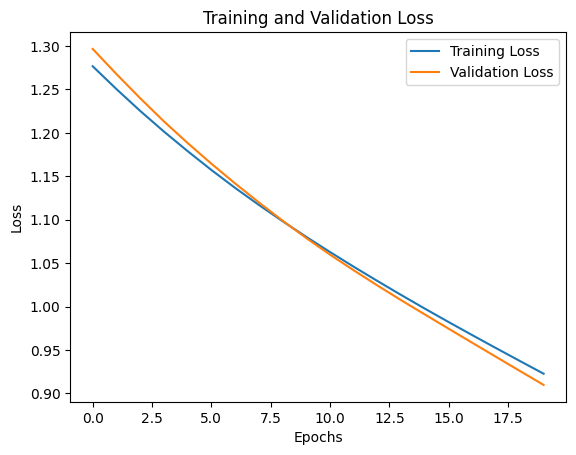

In [94]:
# plot loss vs val_loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

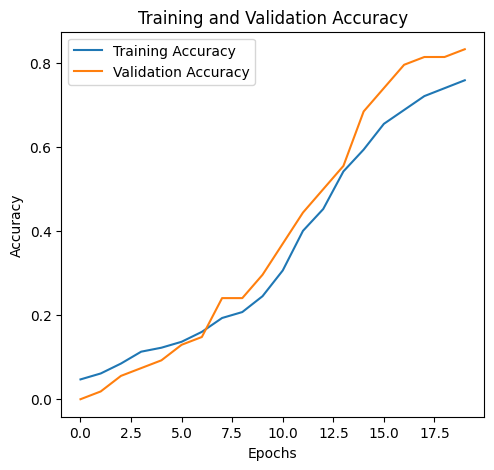

In [95]:
# plot the training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

### Model variability

Define, compile and train the model 3 times and see how your training and validation curves change. Are they the same or different? Why is this happening?

When I defined, compiled, and trained model 3 times, I noticed that the training and validation curves did change each time. This seems to be happening because I did not originally set a seed, so there is inherent randomness. We also only have two hidden layers, so there is a chance that the model is underfitting.

### Setting a random seed

How does setting the tf random seed affect the training and validation curves?

There was slightly less variation when I was rerunning everything and evaluating the results, but definitely still variation. I think this is due to the underfitting from very few hidden layers in the model.

Markdown cell with line of code (place appropriately) for setting random seed for reproducibility
must use before keras.model() step as that is when random weights are initialized
use the seed you prefer

tf.random.set_seed(42)

### Modifying the hidden layers

Try **three** different configurations for the hidden layers. You are welcome to add or remove layers, to try different layer strategies (funnel, flat, etc ) and to vary the number of neurons. For each configuration, record: (1) the architecture you tried, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What seemed to work best?

I only tried configurations that added hidden layers. The first new configuration included a flat strategy:

x = layers.Dense(7, activation = 'relu')(inputs)


x = layers.Dense(7, activation = 'relu')(x)


x = layers.Dense(7, activation = 'relu')(x)


This gave me a test accuracy of 0.4776. The graphs show that training loss is higher than test loss always, but both decrease as epoch value increases. Training accuracy is typically higher than test accuracy and both increase as epoch increases.


Next, I did a configuration using the funnel strategy:

x = layers.Dense(7, activation = 'relu')(inputs)


x = layers.Dense(5, activation = 'relu')(x)


x = layers.Dense(3, activation = 'relu')(x)

This gave me a test accuracy that was lower than before at 0.4030. The gap between training and test loss got bigger, but both are still decreasing as epoch value gets higher. Both training and test accuracy go up until about 5 epochs and then decline.


The last configuration that I tried is an expanding strategy:

x = layers.Dense(7, activation = 'relu')(inputs)


x = layers.Dense(14, activation = 'relu')(x)


x = layers.Dense(21, activation = 'relu')(x)

This test improved the accuracy at 0.6866, which outperformed the previous configurations. After about three epochs, the validation accuracy outperformed the training accuracy. The training and validation loss start close together and then the difference between them increases as epoch value increases. Expanding seemed to be the best, but I would remain cautious to avoid overfitting.



### Modifying the training cycles (epochs)

Vary the number of epochs. For each configuration, record: (1) the number of epochs, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What was the minimum number of epochs needed for reliable model performance?

First, I tried 5 epochs, and this lowered my accuracy to 0.3881. Training loss is higher that test loss until about 2.5 epochs, and then test loss is slightly higher than training loss. Around 2 epoch, test accuracy rises at a higher rate that training accuracy as epoch number increases.

Then, I tried 20 epochs, and got a test accuracy of 0.7910, which showed a huge increase. The test loss was higher than the training loss until about 8 epochs. Training and test accuracy increased as number of epochs increased. 20 seems like it may be the minimum number of epochs needed for reliable model performance.

### Early stopping, l2 regularization and dropout

Doing all these for peguins is probably overkill!

In [ ]:
# sample model

tf.random.set_seed(42)  # set seed for reproducibility

inputs = keras.Input(shape=(6,))  # 6 input features

x = layers.Dense(
    7,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 penalty on weights
)(inputs)
x = layers.Dropout(0.2)(x)  # randomly drop 20% of neurons during training

x = layers.Dense(
    5,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 applied again
)(x)
x = layers.Dropout(0.2)(x)  # dropout applied per layer

x = layers.Dense(
    3,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 on final hidden layer
)(x)
x = layers.Dropout(0.2)(x)  # dropout again (often not needed this deep)

outputs = layers.Dense(3, activation="softmax")(x)  # 3-class output → probabilities

model = keras.Model(inputs=inputs, outputs=outputs)  # build model (initialize weights)

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # multiclass loss
    optimizer=keras.optimizers.Adam(),  # adaptive optimizer
    metrics=["accuracy"]  # track accuracy
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",  # watch validation loss
    patience=5,  # stop after 5 epochs without improvement
    restore_best_weights=True  # keep best-performing weights
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,  # maximum training length
    batch_size=64,
    validation_split=0.2,  # hold out 10% for validation
    callbacks=[early_stop],  # apply early stopping
    verbose=1
)

### Tuning with Optuna

Adjust the code below to have the validation size, epochs and verbosity you found best from above. Then tune your model. You are welcome to increase the number of trials or to add parameters if you desire. Make sure the outputs of your cells are displayed. Then build a final model using your optimized parameters and predict on the test set.

In [50]:
# tuning the model with Optuna

def objective(trial):
    num_layers = trial.suggest_int("num_layers", 1, 3)  # number of hidden layers
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)  # log scale for LR
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])  # common batch sizes

    inputs = keras.Input(shape=(6,))  # 6 input features
    x = inputs

    for i in range(num_layers):
        units = trial.suggest_int(f"num_units_layer_{i+1}", 4, 32)  # neurons per layer
        x = layers.Dense(units, activation="relu")(x)  # hidden layer

    outputs = layers.Dense(3, activation="softmax")(x)  # 3 classes → softmax output
    model = keras.Model(inputs=inputs, outputs=outputs)  # build model

    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # classification loss
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),  # optimizer with tuned LR
        metrics=["accuracy"],  # track accuracy
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",  # watch validation loss
        patience=5,  # stop after 5 epochs without improvement
        restore_best_weights=True  # keep best model weights
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=batch_size,
        epochs=50,  # max training epochs
        validation_split=0.2,  # validation portion of training data
        verbose=0,  # suppress output during tuning
        callbacks=[early_stop]  # apply early stopping
    )

    return min(history.history["val_loss"])  # objective = best validation loss


study = optuna.create_study(direction="minimize")  # minimize validation loss
study.optimize(objective, n_trials=20)  # run 20 trials (20 models)

print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)


[I 2026-05-14 20:20:12,213] A new study created in memory with name: no-name-7074584d-cb44-4d31-a57b-08d6a75bd163
[I 2026-05-14 20:20:19,676] Trial 0 finished with value: 0.022726094350218773 and parameters: {'num_layers': 3, 'learning_rate': 0.0022736335654138192, 'batch_size': 64, 'num_units_layer_1': 8, 'num_units_layer_2': 30, 'num_units_layer_3': 22}. Best is trial 0 with value: 0.022726094350218773.
[I 2026-05-14 20:20:27,122] Trial 1 finished with value: 0.10167756676673889 and parameters: {'num_layers': 3, 'learning_rate': 0.000931844117414679, 'batch_size': 64, 'num_units_layer_1': 20, 'num_units_layer_2': 4, 'num_units_layer_3': 25}. Best is trial 0 with value: 0.022726094350218773.
[I 2026-05-14 20:20:34,643] Trial 2 finished with value: 0.032066673040390015 and parameters: {'num_layers': 2, 'learning_rate': 0.005032093490180095, 'batch_size': 32, 'num_units_layer_1': 5, 'num_units_layer_2': 14}. Best is trial 0 with value: 0.022726094350218773.
[I 2026-05-14 20:20:41,585] T

Best validation loss: 0.022726094350218773
Best parameters: {'num_layers': 3, 'learning_rate': 0.0022736335654138192, 'batch_size': 64, 'num_units_layer_1': 8, 'num_units_layer_2': 30, 'num_units_layer_3': 22}


In [ ]:
# visualizing Optuna results

optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)
optuna.visualization.plot_slice(study)

In [51]:
# Building the best model from Optuna results
best_params = study.best_params
num_layers = best_params["num_layers"]
learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]
inputs = keras.Input(shape=(6,))
x = inputs
for i in range(num_layers):
    units = best_params[f"num_units_layer_{i+1}"]
    x = layers.Dense(units, activation="relu")(x)
outputs = layers.Dense(3, activation="softmax")(x)
best_model = keras.Model(inputs=inputs, outputs=outputs)
best_model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=["accuracy"],
)
history = best_model.fit(X_train_scaled, y_train, batch_size=batch_size, epochs=50, validation_split=0.2, verbose=1, callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)])
scores = best_model.evaluate(X_test_scaled, y_test, verbose=1)

# evaluate the best model using the test set
y_pred_prob = best_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Best Model Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.6462 - loss: 0.9249 - val_accuracy: 0.6481 - val_loss: 0.8262
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6840 - loss: 0.8244 - val_accuracy: 0.8148 - val_loss: 0.7364
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7830 - loss: 0.7443 - val_accuracy: 0.8333 - val_loss: 0.6593
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7877 - loss: 0.6718 - val_accuracy: 0.8333 - val_loss: 0.5888
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7877 - loss: 0.6028 - val_accuracy: 0.8333 - val_loss: 0.5235
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7877 - loss: 0.5364 - val_accuracy: 0.8704 - val_loss: 0.4613
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8160 - loss: 0.4727 - val_accuracy: 0.8704 - val_loss: 0.4058
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8538 - loss: 0.4137 - val_accuracy: 0.8889 - val_loss: 0.3591
